# FleetIQ — NYC TLC Dataset Audit

## 0. Project Objective

This notebook is the first SmartTaxi/FleetIQ technical stage: it understands raw NYC TLC Yellow Taxi records, measures data-quality problems, and writes evidence for a later cleaning notebook. It **does not clean rows, build final features, create a final target, or train ML**.

Raw data → **Dataset audit** → Cleaning rules → `02_data_cleaning.ipynb` → Feature engineering → ML dataset → Trip-duration model.

TLC trip records can support a trip-duration project because they contain pickup/drop-off times. They cannot support driver-to-passenger ETA alone: request time, driver assignment, GPS location, and driver-arrival events are absent.

## 🔍 Audit of the Existing Notebook

### What it did
The previous notebook inventoried and loaded monthly files, measured dimensions, inspected schema/missingness/duplicates/timestamps/distance/passengers/locations, and summarized quality. These all belong in an audit. It also assessed driver-to-passenger ETA feasibility; that conclusion is useful context, but not the main task for a trip-record audit.

### Complexity assessment
- 🟢 Implement yourself: `shape`, `head`, `info`, `describe`, `isna().sum()`, `duplicated().sum()`, boolean filters, `value_counts`, and simple plots.
- 🟡 Understand next: temporary duration Series, per-file summary tables, and lookup validation.
- 🔴 Postpone: project-root discovery helpers, broad `try/except` loaders, seaborn styling, generic role heuristics, many reporting helpers, and a Case-A framework.

### AI over-engineering removed
The old notebook used 18 sections, defensive path/loading code, a dictionary-oriented reporting framework, styling libraries, and several small helpers. They can be useful in production, but make a first audit harder to rebuild. This version uses direct pandas operations and one small numeric helper. It retains per-file processing only because four raw files contain roughly 16 million rows; concatenating them would need much more memory.

## 1. Dataset Loading

### Concept
Find and load the exact raw files.

### Why?
An audit must state what it examined. Dataframes remain separate to keep the notebook practical and to expose month-to-month differences.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path.cwd().parent / 'data' / 'raw' / 'nyc_tlc'
if not DATA_DIR.exists():
    DATA_DIR = Path.cwd() / 'data' / 'raw' / 'nyc_tlc'

trip_files = sorted(DATA_DIR.glob('yellow_tripdata_*.parquet'))
lookup_file = DATA_DIR / 'taxi_zone_lookup.csv'
print('Auditing files:', [f.name for f in trip_files])
if not trip_files:
    raise FileNotFoundError('Put Yellow Taxi Parquet files in data/raw/nyc_tlc and rerun.')

datasets = {f.stem: pd.read_parquet(f) for f in trip_files}
zone_lookup = pd.read_csv(lookup_file) if lookup_file.exists() else None
print('Zone lookup available:', zone_lookup is not None)
# No raw file or raw DataFrame is changed in this notebook.

Auditing files: ['yellow_tripdata_2025-01.parquet', 'yellow_tripdata_2025-04.parquet', 'yellow_tripdata_2025-07.parquet', 'yellow_tripdata_2025-10.parquet']
Zone lookup available: True


### Interpretation and decision
Check the printed file list first. File names suggest coverage, but the temporal audit below verifies the actual date range.

## 2. Dataset Overview

### Concept / Why
Measure scale and preview raw records before interpreting any summary.

In [2]:
overview = pd.DataFrame([{'file': name, 'rows': len(df), 'columns': df.shape[1]}
                         for name, df in datasets.items()])
display(overview)
print('Total rows:', f"{overview['rows'].sum():,}")
for name, df in datasets.items():
    print(f'\n{name}')
    display(df.head(3))

,file,rows,columns
0,yellow_tripdata_2025-01,3475226,20
1,yellow_tripdata_2025-04,3970553,20
2,yellow_tripdata_2025-07,3898963,20
3,yellow_tripdata_2025-10,4428699,20


Total rows: 15,773,441

yellow_tripdata_2025-01


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.6,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.5,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.6,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0



yellow_tripdata_2025-04


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-04-01 00:47:06,2025-04-01 01:13:25,1.0,9.50,1.0,N,138,230,1,38.7,11.0,0.5,11.65,6.94,1.0,69.79,2.5,1.75,0.75
1,2,2025-04-01 00:27:35,2025-04-01 00:38:19,2.0,3.77,1.0,N,138,92,1,17.0,6.0,0.5,4.90,0.00,1.0,31.15,0.0,1.75,0.00
2,2,2025-04-01 00:24:07,2025-04-01 00:35:12,1.0,5.41,1.0,N,132,130,1,22.6,1.0,0.5,5.37,0.00,1.0,32.22,0.0,1.75,0.00



yellow_tripdata_2025-07


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-07-01 00:29:37,2025-07-01 00:45:30,1.0,7.30,1.0,N,138,74,1,29.6,7.75,0.5,9.00,6.94,1.0,54.79,0.0,1.75,0.00
1,1,2025-07-01 00:23:28,2025-07-01 01:07:44,1.0,17.70,2.0,N,132,142,1,70.0,4.25,0.5,5.00,0.00,1.0,80.75,2.5,1.75,0.00
2,2,2025-07-01 00:53:50,2025-07-01 01:27:12,1.0,9.98,1.0,N,138,48,1,43.6,6.00,0.5,10.87,0.00,1.0,66.97,2.5,1.75,0.75



yellow_tripdata_2025-10


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-10-01 00:15:32,2025-10-01 01:04:03,1.0,17.20,2.0,N,132,107,1,70.0,5.0,0.5,0.00,6.94,1.0,83.44,2.5,1.75,0.75
1,7,2025-10-01 00:00:08,2025-10-01 00:00:08,1.0,5.00,1.0,N,107,225,1,28.2,0.0,0.5,8.49,0.00,1.0,42.44,2.5,0.00,0.75
2,2,2025-10-01 00:08:54,2025-10-01 00:14:44,1.0,2.75,1.0,N,263,229,1,12.8,1.0,0.5,3.71,0.00,1.0,22.26,2.5,0.00,0.75


### Decision
The preview only confirms loading and makes fields concrete. It is not data-quality evidence.

## 3. Schema Audit

### Concept
List column name, pandas dtype, missingness, and business role.

### Why?
Timestamp columns can form a diagnostic duration. Location IDs are identifiers, not measurements; fare columns are financial values. Roles help later ML design but do not alter data.

In [3]:
def role_of(column):
    if 'datetime' in column.lower(): return 'datetime'
    if column in ['PULocationID', 'DOLocationID']: return 'location identifier'
    if 'amount' in column.lower() or column in ['mta_tax', 'Airport_fee']: return 'financial variable'
    if column in ['trip_distance', 'passenger_count']: return 'trip characteristic'
    if 'id' in column.lower() or 'type' in column.lower() or 'flag' in column.lower(): return 'categorical / identifier'
    return 'other'

schema_tables = {}
for name, df in datasets.items():
    table = pd.DataFrame({'column': df.columns, 'dtype': df.dtypes.astype(str).values,
                          'missing_count': df.isna().sum().values})
    table['missing_percentage'] = (100 * table['missing_count'] / len(df)).round(2)
    table['role'] = table['column'].map(role_of)
    schema_tables[name] = table
    print(f'\n{name}'); display(table); df.info()


yellow_tripdata_2025-01


,column,dtype,missing_count,missing_percentage,role
0,VendorID,int32,0,0.00,categorical / identifier
1,tpep_pickup_datetime,datetime64[us],0,0.00,datetime
2,tpep_dropoff_datetime,datetime64[us],0,0.00,datetime
3,passenger_count,float64,540149,15.54,trip characteristic
4,trip_distance,float64,0,0.00,trip characteristic
5,RatecodeID,float64,540149,15.54,categorical / identifier
6,store_and_fwd_flag,object,540149,15.54,categorical / identifier
7,PULocationID,int32,0,0.00,location identifier
8,DOLocationID,int32,0,0.00,location identifier
9,payment_type,int64,0,0.00,categorical / identifier


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

,column,dtype,missing_count,missing_percentage,role
0,VendorID,int32,0,0.00,categorical / identifier
1,tpep_pickup_datetime,datetime64[us],0,0.00,datetime
2,tpep_dropoff_datetime,datetime64[us],0,0.00,datetime
3,passenger_count,float64,745730,18.78,trip characteristic
4,trip_distance,float64,0,0.00,trip characteristic
5,RatecodeID,float64,745730,18.78,categorical / identifier
6,store_and_fwd_flag,object,745730,18.78,categorical / identifier
7,PULocationID,int32,0,0.00,location identifier
8,DOLocationID,int32,0,0.00,location identifier
9,payment_type,int64,0,0.00,categorical / identifier


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3970553 entries, 0 to 3970552
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

,column,dtype,missing_count,missing_percentage,role
0,VendorID,int32,0,0.00,categorical / identifier
1,tpep_pickup_datetime,datetime64[us],0,0.00,datetime
2,tpep_dropoff_datetime,datetime64[us],0,0.00,datetime
3,passenger_count,float64,1038755,26.64,trip characteristic
4,trip_distance,float64,0,0.00,trip characteristic
5,RatecodeID,float64,1038755,26.64,categorical / identifier
6,store_and_fwd_flag,object,1038755,26.64,categorical / identifier
7,PULocationID,int32,0,0.00,location identifier
8,DOLocationID,int32,0,0.00,location identifier
9,payment_type,int64,0,0.00,categorical / identifier


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3898963 entries, 0 to 3898962
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

,column,dtype,missing_count,missing_percentage,role
0,VendorID,int32,0,0.00,categorical / identifier
1,tpep_pickup_datetime,datetime64[us],0,0.00,datetime
2,tpep_dropoff_datetime,datetime64[us],0,0.00,datetime
3,passenger_count,float64,990887,22.37,trip characteristic
4,trip_distance,float64,0,0.00,trip characteristic
5,RatecodeID,float64,990887,22.37,categorical / identifier
6,store_and_fwd_flag,object,990887,22.37,categorical / identifier
7,PULocationID,int32,0,0.00,location identifier
8,DOLocationID,int32,0,0.00,location identifier
9,payment_type,int64,0,0.00,categorical / identifier


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4428699 entries, 0 to 4428698
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

### Function note
`role_of` accepts one column name and returns a readable label via a short `if` chain. You should be able to write it yourself; review its labels rather than treating them as truth.

### Decision
Both timestamp columns must exist before a trip-duration project can continue. Any cross-file schema difference should be investigated before later integration.

## 4. Missing-Value Audit

### Concept / Why
Count nulls and percentages for every field. Counts alone cannot be compared between different-sized files. Zero percent is **complete**; any non-zero result is an investigation item—not an automatic rule to drop or fill values.


yellow_tripdata_2025-01


,column,missing_count,missing_percentage,severity
18,Airport_fee,540149,15.54,investigate
3,passenger_count,540149,15.54,investigate
17,congestion_surcharge,540149,15.54,investigate
5,RatecodeID,540149,15.54,investigate
6,store_and_fwd_flag,540149,15.54,investigate
0,VendorID,0,0.00,complete
12,mta_tax,0,0.00,complete
16,total_amount,0,0.00,complete
15,improvement_surcharge,0,0.00,complete
14,tolls_amount,0,0.00,complete



yellow_tripdata_2025-04


,column,missing_count,missing_percentage,severity
18,Airport_fee,745730,18.78,investigate
3,passenger_count,745730,18.78,investigate
17,congestion_surcharge,745730,18.78,investigate
5,RatecodeID,745730,18.78,investigate
6,store_and_fwd_flag,745730,18.78,investigate
0,VendorID,0,0.00,complete
12,mta_tax,0,0.00,complete
16,total_amount,0,0.00,complete
15,improvement_surcharge,0,0.00,complete
14,tolls_amount,0,0.00,complete



yellow_tripdata_2025-07


,column,missing_count,missing_percentage,severity
18,Airport_fee,1038755,26.64,investigate
3,passenger_count,1038755,26.64,investigate
17,congestion_surcharge,1038755,26.64,investigate
5,RatecodeID,1038755,26.64,investigate
6,store_and_fwd_flag,1038755,26.64,investigate
0,VendorID,0,0.00,complete
12,mta_tax,0,0.00,complete
16,total_amount,0,0.00,complete
15,improvement_surcharge,0,0.00,complete
14,tolls_amount,0,0.00,complete



yellow_tripdata_2025-10


,column,missing_count,missing_percentage,severity
18,Airport_fee,990887,22.37,investigate
3,passenger_count,990887,22.37,investigate
17,congestion_surcharge,990887,22.37,investigate
5,RatecodeID,990887,22.37,investigate
6,store_and_fwd_flag,990887,22.37,investigate
0,VendorID,0,0.00,complete
12,mta_tax,0,0.00,complete
16,total_amount,0,0.00,complete
15,improvement_surcharge,0,0.00,complete
14,tolls_amount,0,0.00,complete


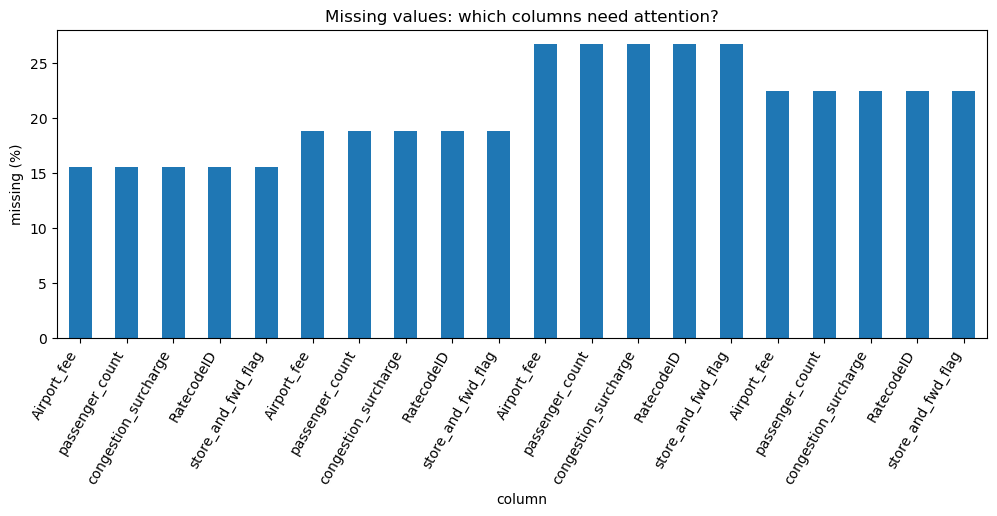

In [4]:
missing_tables = {}
for name, df in datasets.items():
    missing = pd.DataFrame({'column': df.columns, 'missing_count': df.isna().sum().values})
    missing['missing_percentage'] = (100 * missing['missing_count'] / len(df)).round(2)
    missing['severity'] = missing['missing_percentage'].map(lambda x: 'complete' if x == 0 else 'investigate')
    missing_tables[name] = missing.sort_values('missing_percentage', ascending=False)
    print(f'\n{name}'); display(missing_tables[name])

plot_data = pd.concat([x.assign(file=name) for name, x in missing_tables.items()])
plot_data = plot_data[plot_data['missing_count'] > 0]
if not plot_data.empty:
    plot_data.plot.bar(x='column', y='missing_percentage', figsize=(12, 4), legend=False)
    plt.title('Missing values: which columns need attention?'); plt.ylabel('missing (%)')
    plt.xticks(rotation=60, ha='right'); plt.show()

### Interpretation and decision
The chart answers: **which fields are incomplete, and by how much?** It cannot decide whether to impute, retain, or exclude a value. A missing timestamp is more serious for target construction than a missing tip.

## 5. Duplicate Audit

### Concept / Why
Count exact duplicate rows. `duplicated()` compares every field. A duplicate row is not necessarily a duplicate trip, so we measure rather than remove it.

In [5]:
duplicate_summary = pd.DataFrame([
    {'file': name, 'duplicate_count': int(df.duplicated().sum()),
     'duplicate_percentage': round(100 * df.duplicated().mean(), 4)}
    for name, df in datasets.items()
])
display(duplicate_summary)

,file,duplicate_count,duplicate_percentage
0,yellow_tripdata_2025-01,0,0.0
1,yellow_tripdata_2025-04,0,0.0
2,yellow_tripdata_2025-07,1,0.0
3,yellow_tripdata_2025-10,0,0.0


### Decision
If duplicates exist, inspect examples and ingestion history in the cleaning stage. Never silently deduplicate because the audit found a count.

## 6. Temporal Audit

### Concept
Validate pickup/drop-off timestamps and calculate a temporary diagnostic `duration_minutes`.

### Why?
A future trip-duration target is only trustworthy when timestamps are valid. Drop-off before pickup is impossible. Long durations are unusual but can be valid; they are flagged, not deleted.

In [6]:
temporal_rows, duration_by_file = [], {}
for name, df in datasets.items():
    pickup = pd.to_datetime(df['tpep_pickup_datetime'], errors='coerce')
    dropoff = pd.to_datetime(df['tpep_dropoff_datetime'], errors='coerce')
    duration = (dropoff - pickup).dt.total_seconds() / 60
    duration_by_file[name] = duration  # diagnostic only; df is untouched
    temporal_rows.append({
        'file': name, 'missing_pickup': int(pickup.isna().sum()),
        'missing_dropoff': int(dropoff.isna().sum()),
        'dropoff_before_pickup': int((dropoff < pickup).sum()),
        'zero_duration': int((duration == 0).sum()),
        'negative_duration': int((duration < 0).sum()),
        'over_4_hours': int((duration > 240).sum()),
        'earliest_pickup': pickup.min(), 'latest_pickup': pickup.max(),
    })
temporal_summary = pd.DataFrame(temporal_rows)
display(temporal_summary)
for name, duration in duration_by_file.items():
    print(name); display(duration.describe(percentiles=[.01, .5, .95, .99]))

,file,missing_pickup,missing_dropoff,dropoff_before_pickup,zero_duration,negative_duration,over_4_hours,earliest_pickup,latest_pickup
0,yellow_tripdata_2025-01,0,0,124,1927,124,1278,2024-12-31 20:47:55,2025-02-01 00:00:44
1,yellow_tripdata_2025-04,0,0,163,34606,163,1468,2025-03-31 23:45:01,2025-05-01 00:48:13
2,yellow_tripdata_2025-07,0,0,1,56063,1,1073,2009-01-01 08:52:26,2025-07-31 23:59:59
3,yellow_tripdata_2025-10,0,0,2,67966,2,1470,2025-09-30 22:54:51,2025-11-01 00:32:12


yellow_tripdata_2025-01


count    3.475226e+06
mean     1.501812e+01
std      3.871358e+01
min     -5.147232e+04
1%       6.666667e-01
50%      1.170000e+01
95%      3.620000e+01
99%      5.891667e+01
max      5.626317e+03
dtype: float64

yellow_tripdata_2025-04


count    3.970553e+06
mean     1.662804e+01
std      2.950762e+01
min     -1.205833e+02
1%       8.333333e-02
50%      1.293333e+01
95%      4.091667e+01
99%      6.748333e+01
max      1.488077e+04
dtype: float64

yellow_tripdata_2025-07


count    3.898963e+06
mean     1.709947e+01
std      2.543655e+01
min     -1.055000e+01
1%       0.000000e+00
50%      1.353333e+01
95%      4.245000e+01
99%      6.758333e+01
max      7.507400e+03
dtype: float64

yellow_tripdata_2025-10


count    4.428699e+06
mean     1.866700e+01
std      2.676338e+01
min     -4.971333e+02
1%       0.000000e+00
50%      1.455000e+01
95%      4.751667e+01
99%      7.618333e+01
max      8.021650e+03
dtype: float64

### Interpretation and decision
Four hours is an investigation cue, not a documented invalid limit. The full minimum, maximum, and percentiles support a later decision. The first/last pickup verifies true temporal coverage.

### Try it yourself — Exercise 1
Write code to count `tpep_dropoff_datetime < tpep_pickup_datetime` in one DataFrame before consulting the solutions.

## 7. Numerical Validity Audit

### Concept / Why
Inspect distance, passengers, fares, and total amount for missing values, range, centre, percentiles, zeros, negatives, and unusually large values. Negative distance/passenger count is impossible. A zero or unusual value is not automatically an error.

In [7]:
def audit_numeric(df, column, large_value):
    """Return readable measurements for one numeric column; it never changes df."""
    x = pd.to_numeric(df[column], errors='coerce')
    return {'missing': int(x.isna().sum()), 'minimum': x.min(), 'maximum': x.max(),
            'mean': x.mean(), 'median': x.median(), 'p95': x.quantile(.95),
            'p99': x.quantile(.99), 'zeros': int((x == 0).sum()),
            'negatives': int((x < 0).sum()), f'over_{large_value}': int((x > large_value).sum())}

limits = {'trip_distance': 100, 'passenger_count': 6, 'fare_amount': 500, 'total_amount': 500}
numeric_rows = []
for name, df in datasets.items():
    for column, limit in limits.items():
        if column in df: numeric_rows.append({'file': name, 'column': column, **audit_numeric(df, column, limit)})
numeric_summary = pd.DataFrame(numeric_rows)
display(numeric_summary)
# Large values are visibility cues, not cleaning thresholds. Confirm domain rules before deletion.

,file,column,missing,minimum,maximum,mean,median,p95,p99,zeros,negatives,over_100,over_6,over_500
0,yellow_tripdata_2025-01,trip_distance,0,0.00,276423.57,5.855126,1.67,11.83,19.5000,90893,0,162.0,NaN,NaN
1,yellow_tripdata_2025-01,passenger_count,540149,0.00,9.00,1.297859,1.00,3.00,5.0000,24656,0,NaN,18.0,NaN
2,yellow_tripdata_2025-01,fare_amount,0,-900.00,863372.12,17.081803,12.11,52.00,72.3000,1398,144118,NaN,NaN,55.0
3,yellow_tripdata_2025-01,total_amount,0,-901.00,863380.37,25.611292,19.95,74.00,102.9200,559,63037,NaN,NaN,79.0
4,yellow_tripdata_2025-04,trip_distance,0,0.00,386088.43,6.994739,1.80,12.36,19.4100,91439,0,306.0,NaN,NaN
5,yellow_tripdata_2025-04,passenger_count,745730,0.00,9.00,1.308329,1.00,3.00,4.0000,23101,0,NaN,14.0,NaN
6,yellow_tripdata_2025-04,fare_amount,0,-1777.50,1777.50,17.965107,13.50,55.50,75.1000,1451,186720,NaN,NaN,60.0
7,yellow_tripdata_2025-04,total_amount,0,-1793.37,1793.37,26.594928,21.06,76.50,104.0300,614,72608,NaN,NaN,90.0
8,yellow_tripdata_2025-07,trip_distance,0,0.00,397994.37,7.104756,1.91,13.20,19.7200,123774,0,274.0,NaN,NaN
9,yellow_tripdata_2025-07,passenger_count,1038755,0.00,9.00,1.315910,1.00,3.00,4.0000,20544,0,NaN,21.0,NaN


### Function note
`audit_numeric(df, column, large_value)` receives a DataFrame and one field. It returns a dictionary that becomes one report row. Its operations—`min`, `max`, `mean`, `median`, `quantile`, and boolean filters—are all worth practicing and should be explainable in an interview.

### Try it yourself — Exercise 2
Calculate the percentage of rows where `trip_distance <= 0`.

### Try it yourself — Exercise 3
Calculate the median diagnostic duration from `duration_by_file`.

## 8. Location Identifier Audit

### Concept / Why
Audit `PULocationID` and `DOLocationID` as IDs: missingness, range, unique count, frequency, and lookup validity. Their numeric magnitude has no distance meaning; later they should be categorical or joined to zone metadata.

In [8]:
valid_ids = set(zone_lookup['LocationID']) if zone_lookup is not None else set()
location_rows = []
for name, df in datasets.items():
    for column in ['PULocationID', 'DOLocationID']:
        x = pd.to_numeric(df[column], errors='coerce')
        absent = int((~x.isin(valid_ids) & x.notna()).sum()) if valid_ids else None
        location_rows.append({'file': name, 'column': column, 'missing': int(x.isna().sum()),
                              'minimum': x.min(), 'maximum': x.max(), 'unique_count': x.nunique(),
                              'not_in_lookup': absent})
        print(f'\n{name} — frequent {column}'); display(x.value_counts().head(10).rename('trip_count').to_frame())
location_summary = pd.DataFrame(location_rows)
display(location_summary)


yellow_tripdata_2025-01 — frequent PULocationID


,trip_count
PULocationID,
161,169977
237,163703
236,155647
132,146137
230,125829
186,119131
162,117930
142,110585
239,96614



yellow_tripdata_2025-01 — frequent DOLocationID


,trip_count
DOLocationID,
236,161376
237,149970
161,131258
230,108177
170,100060
142,98982
239,97559
162,93798
141,92675



yellow_tripdata_2025-04 — frequent PULocationID


...


yellow_tripdata_2025-10 — frequent PULocationID


,trip_count
PULocationID,
237,205942
132,192927
161,192289
236,180363
162,137873
186,136064
142,133270
230,132168
138,123378



yellow_tripdata_2025-10 — frequent DOLocationID


,trip_count
DOLocationID,
237,187300
236,185810
161,159841
230,125637
170,120743
162,118299
142,117430
68,111646
239,110742


,file,column,missing,minimum,maximum,unique_count,not_in_lookup
0,yellow_tripdata_2025-01,PULocationID,0,1,265,261,0
1,yellow_tripdata_2025-01,DOLocationID,0,1,265,260,0
2,yellow_tripdata_2025-04,PULocationID,0,1,265,261,0
3,yellow_tripdata_2025-04,DOLocationID,0,1,265,261,0
4,yellow_tripdata_2025-07,PULocationID,0,1,265,261,0
5,yellow_tripdata_2025-07,DOLocationID,0,1,265,261,0
6,yellow_tripdata_2025-10,PULocationID,0,1,265,262,0
7,yellow_tripdata_2025-10,DOLocationID,0,1,265,262,0


### Decision
An ID absent from the supplied lookup is suspicious. A high/low ID is not suspicious just because of its number. Do not merge zone names into raw data here.

## 9. Distribution & Outlier Analysis

### Concept / Why
Histograms show the usual range and long tails. They do not prove that a record is invalid. A two-hour trip may be valid; a negative duration cannot be. The visual limit below is only for readability.

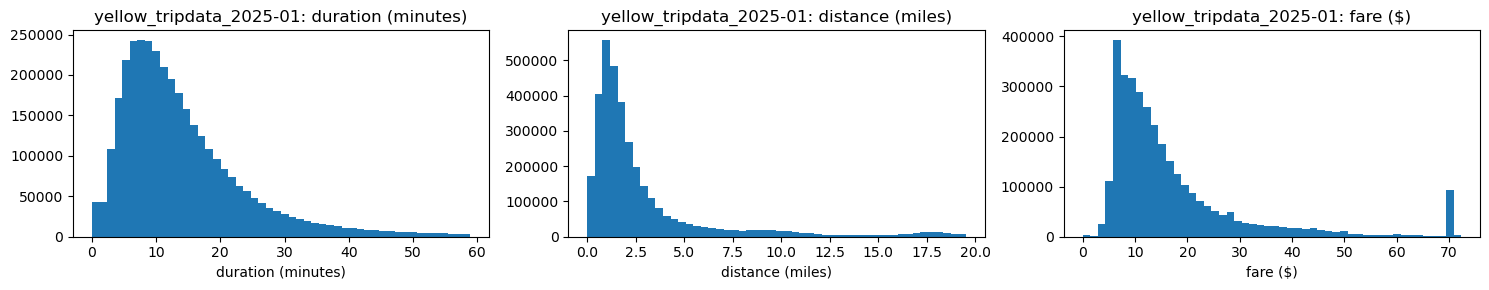

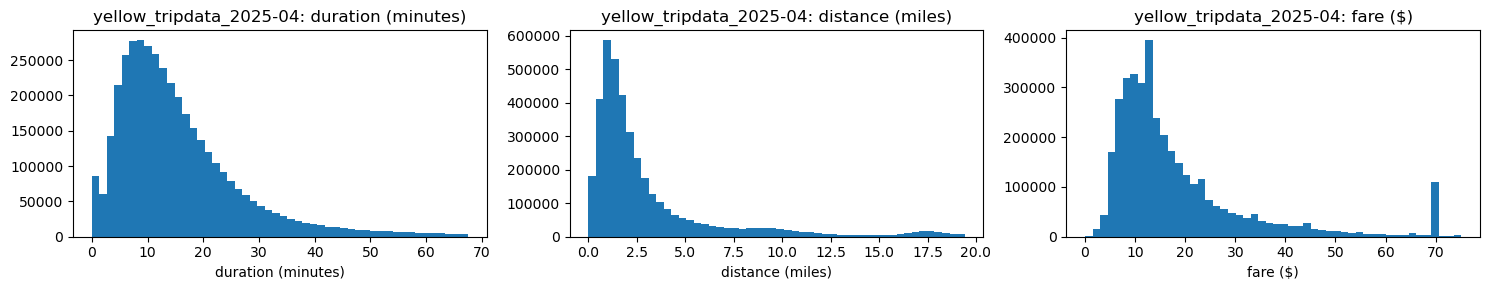

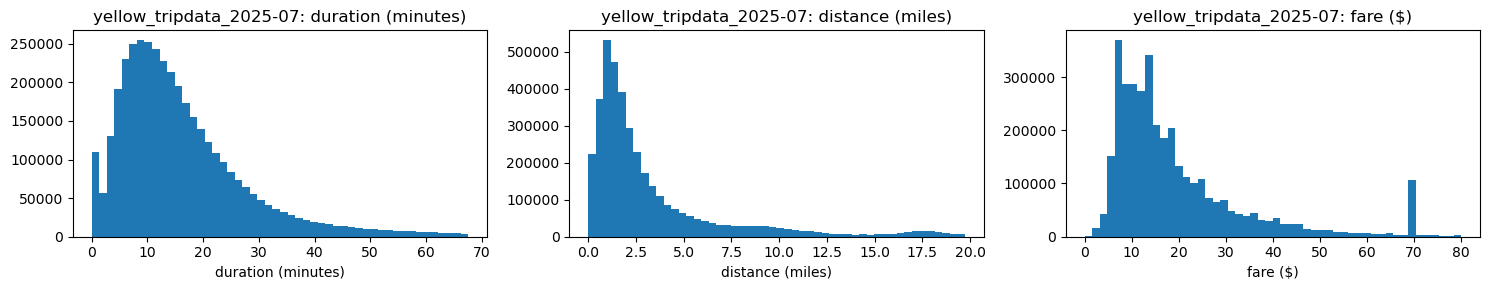

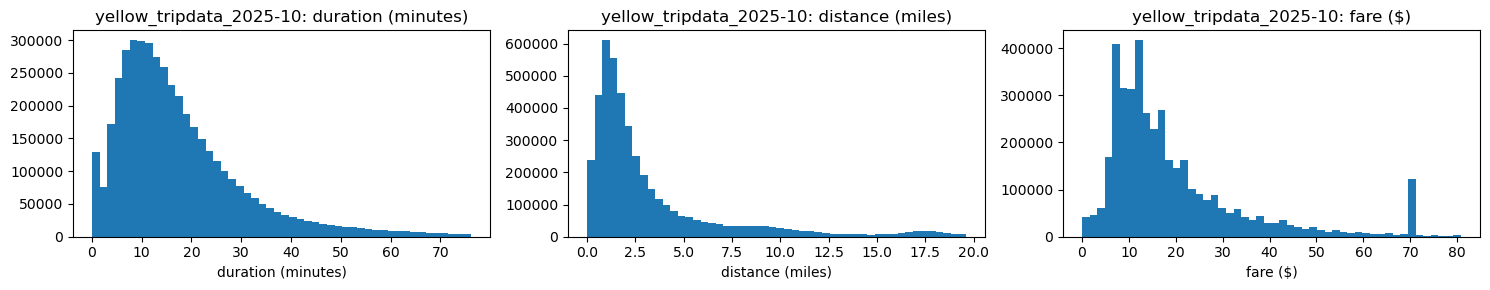

In [9]:
for name, df in datasets.items():
    series = [('duration (minutes)', duration_by_file[name]),
              ('distance (miles)', pd.to_numeric(df['trip_distance'], errors='coerce')),
              ('fare ($)', pd.to_numeric(df['fare_amount'], errors='coerce'))]
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))
    for ax, (label, x) in zip(axes, series):
        upper = x.quantile(.99)
        ax.hist(x[(x >= 0) & (x <= upper)].dropna(), bins=50)
        ax.set_title(f'{name}: {label}'); ax.set_xlabel(label)
    plt.tight_layout(); plt.show()
# Values over p99 are still in the numerical table and are not removed.

### Interpretation and decision
These charts answer: **what is typical, and is there a long tail?** Use the numerical table to inspect full extrema.

### Try it yourself — Exercise 4
Find the 99th percentile of `trip_distance`.

## 10. Cross-Column Consistency

### Concept / Why
Individually plausible values can contradict each other. Check the required relationship `dropoff >= pickup`, `duration > 0`, and suspicious combinations such as zero duration with positive distance.

In [10]:
consistency_rows = []
for name, df in datasets.items():
    pickup = pd.to_datetime(df['tpep_pickup_datetime'], errors='coerce')
    dropoff = pd.to_datetime(df['tpep_dropoff_datetime'], errors='coerce')
    duration = (dropoff - pickup).dt.total_seconds() / 60
    distance = pd.to_numeric(df['trip_distance'], errors='coerce')
    consistency_rows.append({'file': name,
        'dropoff_before_pickup': int((dropoff < pickup).sum()),
        'duration_not_positive': int((duration <= 0).sum()),
        'zero_duration_positive_distance': int(((duration == 0) & (distance > 0)).sum()),
        'positive_duration_negative_distance': int(((duration > 0) & (distance < 0)).sum())})
consistency_summary = pd.DataFrame(consistency_rows)
display(consistency_summary)

,file,dropoff_before_pickup,duration_not_positive,zero_duration_positive_distance,positive_duration_negative_distance
0,yellow_tripdata_2025-01,124,2051,1235,0
1,yellow_tripdata_2025-04,163,34769,33770,0
2,yellow_tripdata_2025-07,1,56064,54554,0
3,yellow_tripdata_2025-10,2,67968,66633,0


### Decision
Impossible relationships are strong candidates for cleaning rules. Suspicious combinations require example review and domain context first.

## 11. Data Quality Summary

### Concept / Why
Create one evidence table. `WARNING` needs a policy; `CRITICAL` is an impossible condition or prevents duration construction. The conclusion must come from measurements, not fabricated values.

In [11]:
total_rows = int(overview['rows'].sum())
def result(label, values, interpretation, critical=False):
    count = int(values.sum())
    return [label, 'CRITICAL' if count and critical else ('WARNING' if count else 'PASS'),
            count, round(100 * count / total_rows, 4), interpretation]

distance = numeric_summary[numeric_summary['column'] == 'trip_distance']
fare = numeric_summary[numeric_summary['column'] == 'fare_amount']
quality_summary = pd.DataFrame([
    result('Missing pickup time', temporal_summary['missing_pickup'], 'Cannot calculate duration.', True),
    result('Missing dropoff time', temporal_summary['missing_dropoff'], 'Cannot calculate duration.', True),
    result('Dropoff before pickup', temporal_summary['dropoff_before_pickup'], 'Physically impossible duration.', True),
    result('Zero duration', temporal_summary['zero_duration'], 'Investigate before target creation.'),
    result('Negative trip distance', distance['negatives'], 'Impossible measurement.', True),
    result('Zero trip distance', distance['zeros'], 'May be valid or a recording issue.'),
    result('Negative fare', fare['negatives'], 'May be adjustment/refund; investigate.'),
    result('Invalid location ID', location_summary['not_in_lookup'].dropna(), 'Not in supplied lookup.'),
 ], columns=['check', 'status', 'count', 'percentage', 'interpretation'])
display(quality_summary)

,check,status,count,percentage,interpretation
0,Missing pickup time,PASS,0,0.0000,Cannot calculate duration.
1,Missing dropoff time,PASS,0,0.0000,Cannot calculate duration.
2,Dropoff before pickup,CRITICAL,290,0.0018,Physically impossible duration.
3,Zero duration,WARNING,160562,1.0179,Investigate before target creation.
4,Negative trip distance,PASS,0,0.0000,Impossible measurement.
5,Zero trip distance,WARNING,431705,2.7369,May be valid or a recording issue.
6,Negative fare,WARNING,899233,5.7009,May be adjustment/refund; investigate.
7,Invalid location ID,PASS,0,0.0000,Not in supplied lookup.


## 12. Proposed Cleaning Rules

This is a specification for the next notebook—not cleaning. Each rule is generated only when the audit observed a problem. It includes evidence, reason, and estimated impact.

In [12]:
rules = []
for _, x in quality_summary[quality_summary['count'] > 0].iterrows():
    if x['check'] == 'Dropoff before pickup':
        rule, reason = 'Remove rows where dropoff is before pickup.', 'Negative duration is physically impossible.'
    elif x['check'] in ['Missing pickup time', 'Missing dropoff time']:
        rule, reason = 'Exclude from duration-target creation; retain raw record unchanged.', 'Both timestamps are required.'
    elif x['check'] == 'Negative trip distance':
        rule, reason = 'Confirm source convention, then exclude if invalid.', 'Negative distance is impossible.'
    else:
        rule, reason = 'Inspect examples and document a policy before changing rows.', x['interpretation']
    rules.append({'problem detected': x['check'], 'evidence': f"{x['count']:,} rows ({x['percentage']}%)",
                  'proposed rule': rule, 'reason': reason,
                  'expected impact': f"Up to {x['count']:,} rows affected; verify first."})
cleaning_rules = pd.DataFrame(rules)
display(cleaning_rules if not cleaning_rules.empty else pd.DataFrame({'message': ['No detected issues require a rule.']}))

,problem detected,evidence,proposed rule,reason,expected impact
0,Dropoff before pickup,290 rows (0.0018%),Remove rows where dropoff is before pickup.,Negative duration is physically impossible.,Up to 290 rows affected; verify first.
1,Zero duration,"160,562 rows (1.0179%)",Inspect examples and document a policy before ...,Investigate before target creation.,"Up to 160,562 rows affected; verify first."
2,Zero trip distance,"431,705 rows (2.7369%)",Inspect examples and document a policy before ...,May be valid or a recording issue.,"Up to 431,705 rows affected; verify first."
3,Negative fare,"899,233 rows (5.7009%)",Inspect examples and document a policy before ...,May be adjustment/refund; investigate.,"Up to 899,233 rows affected; verify first."


## 13. Final Audit Verdict

- **CRITICAL PROBLEMS**: one or both required timestamp fields are absent.
- **USABLE WITH CLEANING**: timestamps exist, but the audit found missing, impossible, or suspicious records requiring a policy.
- **USABLE**: timestamps exist and every reported check passes.

This is a data-quality verdict for trip-duration work, not a model-performance claim.

In [13]:
required = {'tpep_pickup_datetime', 'tpep_dropoff_datetime'}
timestamps_exist = all(required.issubset(df.columns) for df in datasets.values())
if not timestamps_exist:
    verdict = 'CRITICAL PROBLEMS'
elif (quality_summary['status'] != 'PASS').any():
    verdict = 'USABLE WITH CLEANING'
else:
    verdict = 'USABLE'
print('FINAL AUDIT VERDICT:', verdict)
print('Evidence: Data Quality Summary and Proposed Cleaning Rules.')

FINAL AUDIT VERDICT: USABLE WITH CLEANING
Evidence: Data Quality Summary and Proposed Cleaning Rules.


## 14. Exercises

1. Calculate missing percentage for `passenger_count`.
2. Count `trip_distance <= 0`.
3. Count `dropoff < pickup`.
4. Calculate median duration.
5. Find the 99th percentile of trip distance.

### Solutions
```python
df = next(iter(datasets.values()))
100 * df['passenger_count'].isna().mean()
(df['trip_distance'] <= 0).sum()
(df['tpep_dropoff_datetime'] < df['tpep_pickup_datetime']).sum()
((df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60).median()
df['trip_distance'].quantile(.99)
```

## 15. Can I Rebuild This Notebook?

- [ ] Load Parquet data and inspect shape/preview
- [ ] Inspect columns and dtypes
- [ ] Measure missing values and duplicates
- [ ] Validate timestamps and calculate diagnostic duration
- [ ] Audit numerical values and percentiles
- [ ] Validate location identifiers
- [ ] Inspect distributions and cross-column rules
- [ ] Summarize evidence, propose cleaning rules, state a verdict

## 16. What I Learned / Knowledge Boundary

**Must know:** DataFrames, boolean filters, nulls, datetime arithmetic, `value_counts`, statistics/percentiles, matplotlib, validation concepts.

**Understand conceptually:** outliers are not automatically errors; domain constraints differ from rarity; identifiers are not continuous values; timestamp quality controls target quality; audit findings precede cleaning.

**Can delegate later:** repetitive reporting, chart styling, boilerplate, and refactoring—after understanding the calculations.

### Final self-test
Can you explain every function, each audit check, each rule’s evidence, and why raw data was never silently cleaned? If not, rebuild one section from the checklist before moving to the cleaning notebook.